Why the hypothesis family? 

This is a *limiting* factor, which seems to stop one to achieve better accuracy / performance. However, this limitation is crucial in machine learning. It is this limit that introduces necessary "inductive biases". The "biases" allow the model to generalize beyond the training data. 

We will see an example, where without imposing any restrictions except toto adhere to the training data (perfect match!) 

We will see that this lacks the ability to predict on unseen instances. 

Lack of prior limitations leads to overfit to the data.

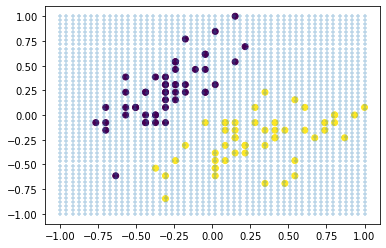

In [1]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
X, y = X[:100, :2], (y[:100]-0.5)*2

# Center and normalize each feature to [-1,1]
X = X - np.mean(X, axis=0)
X = X / np.max(np.abs(X), axis=0)

import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)

grid_num = 50
xgrid, ygrid = np.meshgrid(np.linspace(-1, 1, grid_num), np.linspace(-1, 1, grid_num))
gridsamples = np.stack([xgrid.flatten(), ygrid.flatten()]).T

plt.scatter(gridsamples[:, 0], gridsamples[:, 1], s=10, alpha=0.3, marker='+')

In [2]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
X, y = X[:100, :2], (y[:100]-0.5)*2

# Center and normalize each feature to [-1,1]
X = X - np.mean(X, axis=0)
X = X / np.max(np.abs(X), axis=0)

grid_num = 50
xgrid, ygrid = np.meshgrid(np.linspace(-1, 1, grid_num), np.linspace(-1, 1, grid_num))
gridsamples = np.stack([xgrid.flatten(), ygrid.flatten()]).T

def fit_train(gridsamples, X, y, d=0.023):
    constraints = {}

    for i, xi in enumerate(X):
        dist = np.linalg.norm(gridsamples - xi, axis=1)
        idxs = np.where(dist < d)[0]
        for idx in idxs:
            constraints[idx] = [gridsamples[idx, 0], gridsamples[idx, 1], y[i]]
    return constraints

def get_h(gridsamples, constraints, rng=None):
    if rng is None:
        rng = np.random.RandomState(42)
    gridlabels = []
    for i in range(len(gridsamples)):
        if i in constraints:
            gridlabels.append(constraints[i][-1])
        else:
            gridlabels.append(rng.choice([-1, 1]))
    return gridlabels

rng = np.random.RandomState(42)
constraints = fit_train(gridsamples, X, y)

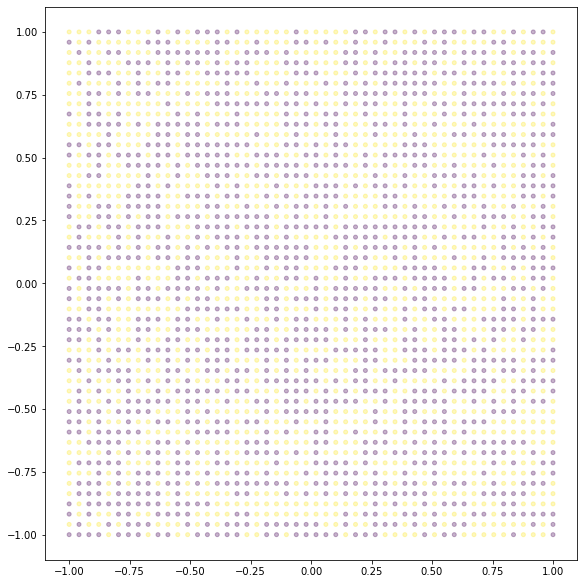

In [5]:
import matplotlib.pyplot as plt

fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8,8))
# ax2.scatter(X[:, 0], X[:, 1], c=y, s=100, marker='s', alpha=0.5)

constraints = {}
gridlabels = get_h(gridsamples, constraints, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)
if len(constraints_disp)>0:
    ax2.scatter(constraints_disp[:, 0], constraints_disp[:, 1], c=constraints_disp[:, 2], s=100, marker='+')

In [ ]:
# How may possiblilies?
n0 = 2 ** len(gridsamples)
print(n0)

Fit 908 gridsamples


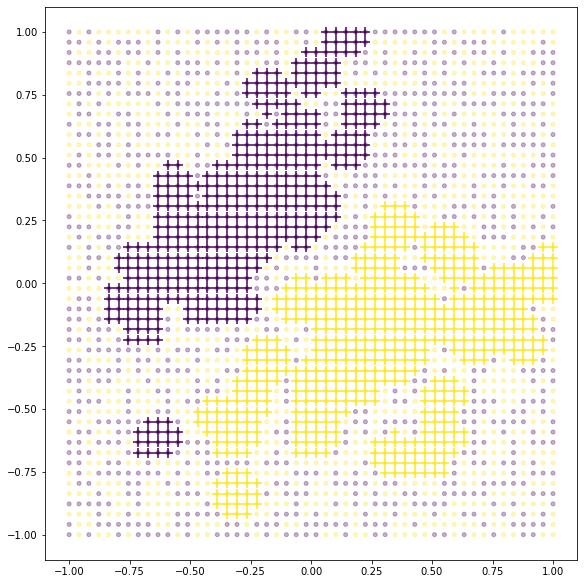

In [8]:
fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8, 8))
#constraints = fit_train(gridsamples, X, y, d=0.025)
constraints = fit_train(gridsamples, X, y, d=0.1)
print(f"Fit {len(constraints)} gridsamples")
gridlabels = get_h(gridsamples, constraints, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)
if len(constraints_disp)>0:
    ax2.scatter(constraints_disp[:, 0], constraints_disp[:, 1], c=constraints_disp[:, 2], s=100, marker='+')

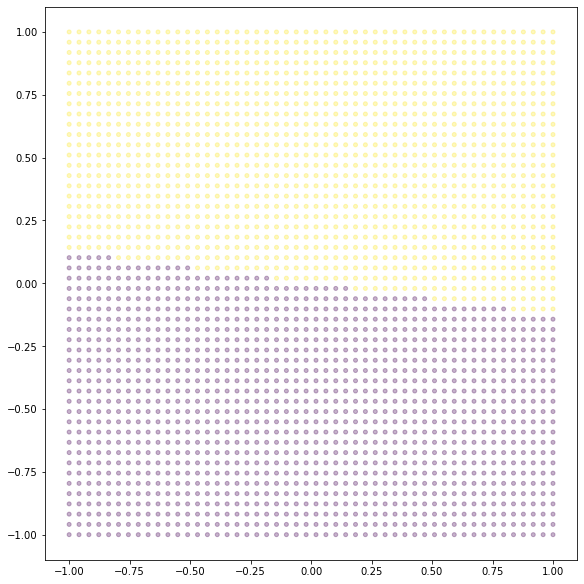

In [11]:
def get_lin_h(data, rng):
    w = rng.rand(2)
    return data[:, 0] * w[0] + data[:, 1] * w[1] > 0

fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8, 8))
gridlabels = get_lin_h(gridsamples, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)

In [ ]:
n1 = 2**(len(gridsamples) - len(constraints))


print(f"The possible solutions is now 1/{2**len(constraints)}")

print(f"Now there are only \n", n1, "\npossibilities")